Packages loaded successfully.

PROBLEM STATEMENT
-----------------
What is the range of potential financial losses Amazon could face
from a significant technology reliability or AI integration failure
event affecting Amazon Connect and AWS Bedrock?

Because the exact cost of a cloud reliability incident cannot be
known in advance, this notebook uses Monte Carlo simulation to
estimate a probability-weighted range of possible financial loss
outcomes rather than relying on a single fixed number.

── Simulation Assumptions ──────────────────────────────────
   Scenario Loss Range ($M)                                                   Interpretation
 Optimistic      $5M – $20M    Brief, quickly-resolved incident with minimal customer impact
Most Likely     $20M – $80M Localized outage with moderate service credits and limited churn
Pessimistic   $100M – $300M  Prolonged multi-region outage with major SLA breaches and churn

── First 5 Simulation Rows ─────────────────────────────────
 Optim

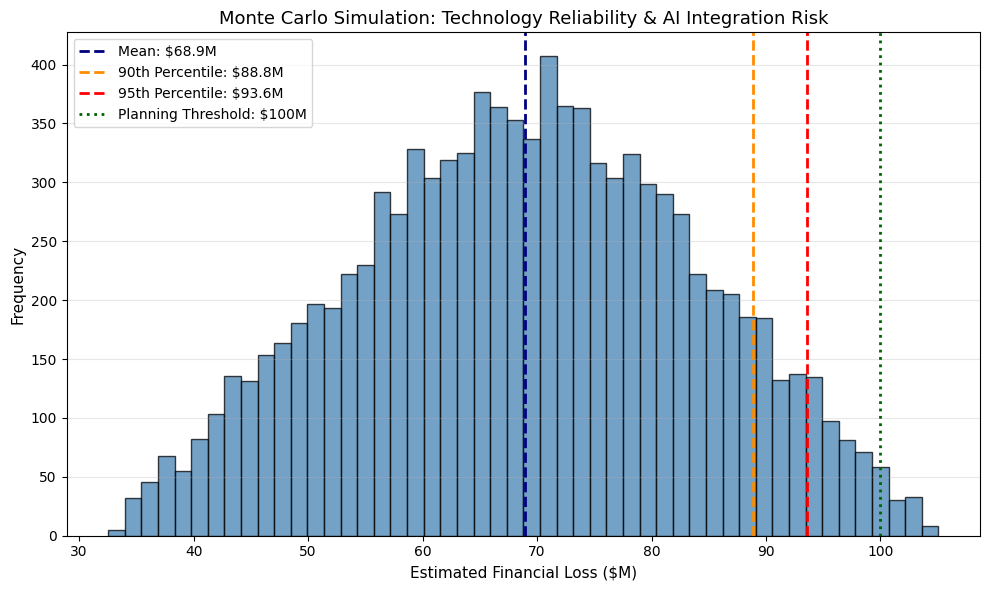

Chart 1 saved: R2_chart_distribution.png

── Threshold Exceedance Probabilities ──────────────────────
 Loss Threshold ($M) Probability of Exceeding (%)
                  50                       88.34%
                  75                       35.15%
                 100                        0.98%
                 125                        0.00%
                 150                        0.00%


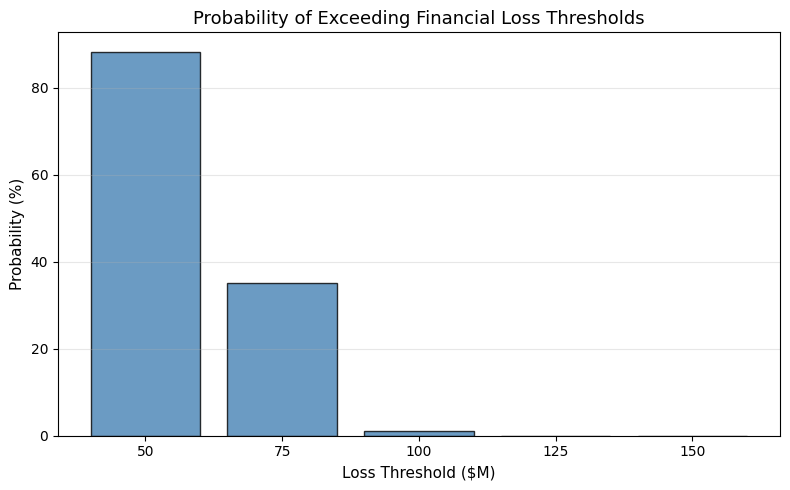

Chart 2 saved: R2_chart_thresholds.png

── I&W Indicator vs. Simulation Percentile Mapping ────────
I&W Zone System Uptime AI Response Accuracy Expected Loss Range Simulation Percentile
   Green        >99.9%                 >90%          $5M – $30M            Below 25th
  Yellow   99.0%–99.9%              80%–90%         $30M – $80M           25th – 75th
     Red        <99.0%                 <80%        $80M – $300M            Above 75th

── Interpretation & Conclusion ────────────────────────────────

Risk:              Technology Reliability & AI Integration Risk
Qualitative Score: Likelihood = 6/9 | Impact = 8/9 | Risk Score = 48

Monte Carlo Simulation Results (10,000 iterations, PERT-weighted):
  Mean Expected Loss            : $68.92M
  Median Loss                   : $69.08M
  90th Percentile Loss          : $88.83M
  95th Percentile Loss          : $93.57M
  Maximum Simulated Loss        : $105.07M
  Probability of Loss > $100M   : 0.98%

The expected financial loss from a si

In [1]:
# =============================================================
# ALY6130 - Risk Management for Analytics
# Assignment 4 - Quantitative Risk Assessment
# Group 3 | Member B
# Risk 2: Technology Reliability & AI Integration Risk
# Monte Carlo Simulation
# =============================================================

# ── STEP 1: Install / import packages ────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Packages loaded successfully.")


# ── STEP 2: Problem Statement ─────────────────────────────────
print("""
PROBLEM STATEMENT
-----------------
What is the range of potential financial losses Amazon could face
from a significant technology reliability or AI integration failure
event affecting Amazon Connect and AWS Bedrock?

Because the exact cost of a cloud reliability incident cannot be
known in advance, this notebook uses Monte Carlo simulation to
estimate a probability-weighted range of possible financial loss
outcomes rather than relying on a single fixed number.
""")


# ── STEP 3: Simulation Assumptions ───────────────────────────
# All loss values are in millions of dollars ($M).
# Three-point PERT-weighted estimates based on:
#   - AWS incident history and industry benchmarks
#   - Risk register qualitative likelihood (6/9) and impact (8/9) scores

np.random.seed(42)          # ensures reproducible results
n_simulations = 10_000      # number of Monte Carlo iterations

# Loss ranges per scenario ($M)
optimistic_min,  optimistic_max  =   5,  20   # brief, contained incident
most_likely_min, most_likely_max =  20,  80   # localized outage
pessimistic_min, pessimistic_max = 100, 300   # prolonged multi-region outage

assumption_table = pd.DataFrame({
    "Scenario"       : ["Optimistic",  "Most Likely",  "Pessimistic"],
    "Loss Range ($M)": ["$5M – $20M",  "$20M – $80M",  "$100M – $300M"],
    "Interpretation" : [
        "Brief, quickly-resolved incident with minimal customer impact",
        "Localized outage with moderate service credits and limited churn",
        "Prolonged multi-region outage with major SLA breaches and churn"
    ]
})

print("── Simulation Assumptions ──────────────────────────────────")
print(assumption_table.to_string(index=False))


# ── STEP 4: Run Monte Carlo Simulation ───────────────────────
# Random values are drawn uniformly within each scenario range,
# then combined using the PERT-weighted formula:
#   Estimated Loss = (Optimistic + 4 × Most Likely + Pessimistic) / 6

optimistic_loss  = np.random.uniform(optimistic_min,  optimistic_max,  n_simulations)
most_likely_loss = np.random.uniform(most_likely_min, most_likely_max, n_simulations)
pessimistic_loss = np.random.uniform(pessimistic_min, pessimistic_max, n_simulations)

estimated_loss = (optimistic_loss + 4 * most_likely_loss + pessimistic_loss) / 6

simulation_df = pd.DataFrame({
    "Optimistic Loss ($M)" : optimistic_loss,
    "Most Likely Loss ($M)": most_likely_loss,
    "Pessimistic Loss ($M)": pessimistic_loss,
    "Estimated Loss ($M)"  : estimated_loss
})

print("\n── First 5 Simulation Rows ─────────────────────────────────")
print(simulation_df.head().to_string(index=False))


# ── STEP 5: Summary Statistics ───────────────────────────────
print("\n── Summary Statistics ──────────────────────────────────────")
print(simulation_df["Estimated Loss ($M)"].describe(
    percentiles=[0.05, 0.25, 0.50, 0.75, 0.90, 0.95]
).round(2))


# ── STEP 6: Report-Ready Results Table ───────────────────────
mean_loss          = simulation_df["Estimated Loss ($M)"].mean()
median_loss        = simulation_df["Estimated Loss ($M)"].median()
p90_loss           = simulation_df["Estimated Loss ($M)"].quantile(0.90)
p95_loss           = simulation_df["Estimated Loss ($M)"].quantile(0.95)
max_loss           = simulation_df["Estimated Loss ($M)"].max()
planning_threshold = 100   # $M — aligned to 90th percentile reserve planning
prob_exceed        = (simulation_df["Estimated Loss ($M)"] > planning_threshold).mean()

result_table = pd.DataFrame({
    "Metric": [
        "Mean Loss",
        "Median Loss",
        "90th Percentile Loss",
        "95th Percentile Loss",
        "Maximum Simulated Loss",
        "Planning Threshold",
        "Probability of Exceeding $100M Threshold"
    ],
    "Value": [
        f"${mean_loss:.2f}M",
        f"${median_loss:.2f}M",
        f"${p90_loss:.2f}M",
        f"${p95_loss:.2f}M",
        f"${max_loss:.2f}M",
        f"${planning_threshold}M",
        f"{prob_exceed * 100:.2f}%"
    ]
})

print("\n── Key Results ─────────────────────────────────────────────")
print(result_table.to_string(index=False))


# ── STEP 7: Loss Distribution Chart ──────────────────────────
plt.figure(figsize=(10, 6))
plt.hist(estimated_loss, bins=50, edgecolor='black', alpha=0.75, color='steelblue')
plt.axvline(mean_loss,           color='navy',       linestyle='--', linewidth=2,
            label=f'Mean: ${mean_loss:.1f}M')
plt.axvline(p90_loss,            color='darkorange',  linestyle='--', linewidth=2,
            label=f'90th Percentile: ${p90_loss:.1f}M')
plt.axvline(p95_loss,            color='red',         linestyle='--', linewidth=2,
            label=f'95th Percentile: ${p95_loss:.1f}M')
plt.axvline(planning_threshold,  color='darkgreen',   linestyle=':',  linewidth=2,
            label=f'Planning Threshold: ${planning_threshold}M')

plt.title("Monte Carlo Simulation: Technology Reliability & AI Integration Risk", fontsize=13)
plt.xlabel("Estimated Financial Loss ($M)", fontsize=11)
plt.ylabel("Frequency", fontsize=11)
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("R2_chart_distribution.png", dpi=150)
plt.show()
print("Chart 1 saved: R2_chart_distribution.png")


# ── STEP 8: Threshold Exceedance Chart ───────────────────────
thresholds  = [50, 75, 100, 125, 150]
prob_values = [(simulation_df["Estimated Loss ($M)"] > t).mean() * 100
               for t in thresholds]

threshold_df = pd.DataFrame({
    "Loss Threshold ($M)"              : thresholds,
    "Probability of Exceeding (%)"     : [f"{p:.2f}%" for p in prob_values]
})

print("\n── Threshold Exceedance Probabilities ──────────────────────")
print(threshold_df.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.bar([str(t) for t in thresholds], prob_values,
        color='steelblue', edgecolor='black', alpha=0.8)
plt.title("Probability of Exceeding Financial Loss Thresholds", fontsize=13)
plt.xlabel("Loss Threshold ($M)", fontsize=11)
plt.ylabel("Probability (%)", fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("R2_chart_thresholds.png", dpi=150)
plt.show()
print("Chart 2 saved: R2_chart_thresholds.png")


# ── STEP 9: I&W Indicator Comparison Table ───────────────────
iw_table = pd.DataFrame({
    "I&W Zone"              : ["Green",        "Yellow",         "Red"],
    "System Uptime"         : [">99.9%",        "99.0%–99.9%",    "<99.0%"],
    "AI Response Accuracy"  : [">90%",          "80%–90%",        "<80%"],
    "Expected Loss Range"   : ["$5M – $30M",    "$30M – $80M",    "$80M – $300M"],
    "Simulation Percentile" : ["Below 25th",    "25th – 75th",    "Above 75th"]
})

print("\n── I&W Indicator vs. Simulation Percentile Mapping ────────")
print(iw_table.to_string(index=False))


# ── STEP 10: Interpretation ───────────────────────────────────
print(f"""
── Interpretation & Conclusion ────────────────────────────────

Risk:              Technology Reliability & AI Integration Risk
Qualitative Score: Likelihood = 6/9 | Impact = 8/9 | Risk Score = 48

Monte Carlo Simulation Results (10,000 iterations, PERT-weighted):
  Mean Expected Loss            : ${mean_loss:.2f}M
  Median Loss                   : ${median_loss:.2f}M
  90th Percentile Loss          : ${p90_loss:.2f}M
  95th Percentile Loss          : ${p95_loss:.2f}M
  Maximum Simulated Loss        : ${max_loss:.2f}M
  Probability of Loss > $100M   : {prob_exceed * 100:.2f}%

The expected financial loss from a significant technology reliability
event is approximately ${mean_loss:.1f}M. The 90th percentile loss of
${p90_loss:.1f}M is the recommended contingency planning threshold.
The 95th percentile of ${p95_loss:.1f}M defines the tail-risk boundary
for worst-case financial reserve planning.

When I&W indicators enter yellow or red zones (e.g. uptime drops
below 99.5%, AI accuracy falls below 85%), Amazon's operational teams
should initiate contingency protocols before losses escalate toward
the 90th or 95th percentile thresholds.
""")